In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv("Social_Network_Ads.csv")
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [3]:
X = df.iloc[:,:-1].values
y = df.iloc[:,-1].values

In [4]:
df.Purchased.value_counts()

0    257
1    143
Name: Purchased, dtype: int64

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2,stratify=y)

In [6]:
print(X_train)

[[    27  58000]
 [    49 141000]
 [    35  60000]
 [    46  22000]
 [    39  59000]
 [    24  58000]
 [    46 117000]
 [    37  55000]
 [    18  86000]
 [    57  60000]
 [    36  54000]
 [    26  81000]
 [    56 133000]
 [    45  45000]
 [    24  55000]
 [    35  20000]
 [    25  79000]
 [    50  36000]
 [    43 129000]
 [    33  31000]
 [    48 138000]
 [    21  68000]
 [    49  28000]
 [    27  58000]
 [    57  26000]
 [    34  43000]
 [    33  51000]
 [    48 131000]
 [    40  75000]
 [    49  74000]
 [    21  72000]
 [    26  72000]
 [    42  53000]
 [    53 143000]
 [    35  27000]
 [    28 123000]
 [    37 144000]
 [    35  44000]
 [    35  50000]
 [    39  61000]
 [    47  20000]
 [    46  32000]
 [    41  72000]
 [    37  77000]
 [    35  47000]
 [    47  25000]
 [    46  74000]
 [    27  17000]
 [    49  88000]
 [    31  68000]
 [    43 112000]
 [    26  35000]
 [    18  44000]
 [    38 113000]
 [    39  42000]
 [    58  95000]
 [    19  25000]
 [    42  65000]
 [    24  2300

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'EstimatedSalary'}>],
       [<Axes: title={'center': 'Purchased'}>, <Axes: >]], dtype=object)

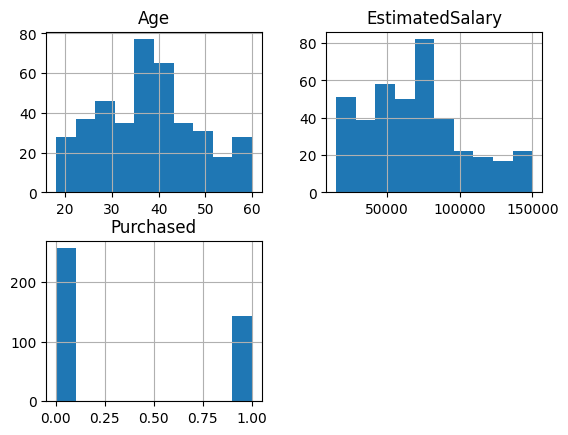

In [7]:
df.hist()

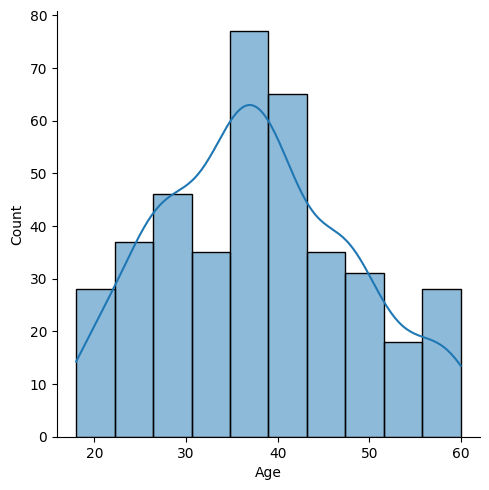

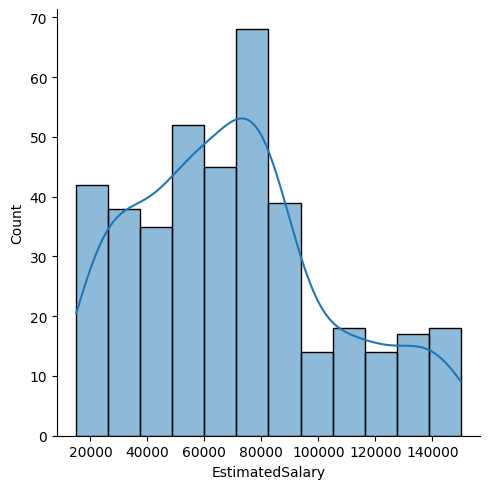

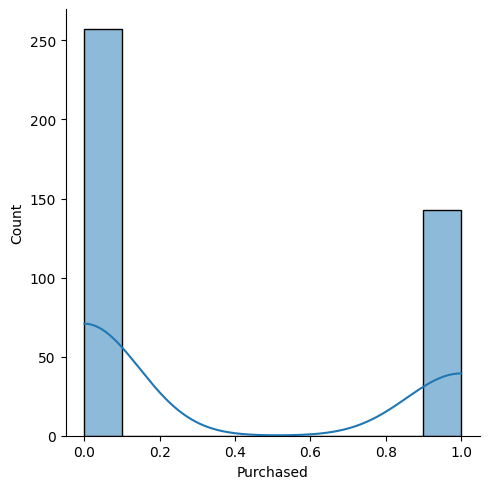

In [8]:
import seaborn as sns
for item in list(df.columns):
  sns.displot(data=df[item],kde=True)

In [9]:
pd.DataFrame(data=y_train).value_counts()

0    206
1    114
dtype: int64

In [10]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

In [11]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state=0)
classifier.fit(X_train_sc,y_train)

LogisticRegression(random_state=0)

In [12]:
print(classifier.predict(sc.transform([[30,87000]])))

[0]


In [13]:
y_pred = classifier.predict(X_test_sc)

In [14]:
print(np.concatenate((y_pred.reshape(len(y_pred),1),y_test.reshape(len(y_test),1)),1))

[[1 1]
 [1 1]
 [1 1]
 [0 1]
 [0 0]
 [0 1]
 [1 1]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 0]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 1]
 [1 0]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]]


In [15]:
from sklearn.metrics import confusion_matrix,accuracy_score
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[48  3]
 [ 9 20]]


<ipython-input-17-141484e8c98a>:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set==j,0],X_set[y_set==j,1],c = ListedColormap(("black","white"))(i),label=j)


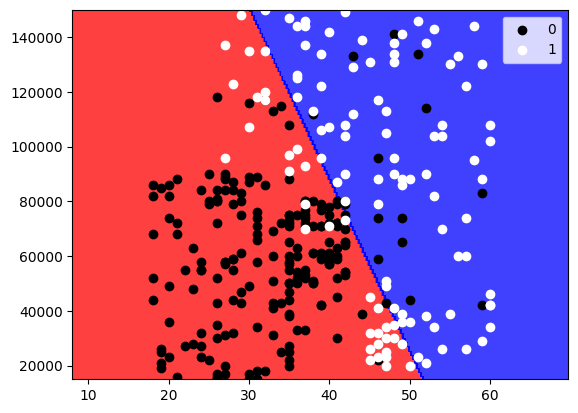

In [17]:
from matplotlib.colors import ListedColormap
X_set,y_set = sc.inverse_transform(X_train_sc),y_train
X1,X2 = np.meshgrid(np.arange(start=X_set[:,0].min()-10,stop=X_set[:,0].max()+10,step=0.25),
                    np.arange(start=X_set[:,1].min()-10,stop=X_set[:,1].max()+10,step=0.25))
plt.contourf(X1,X2,classifier.predict(sc.transform(np.array([X1.ravel(),X2.ravel()]).T)).reshape(X1.shape),
             alpha=0.75,cmap=ListedColormap(('red','blue')))
plt.xlim(X1.min(),X1.max())
plt.ylim(X2.min(),X2.max())
for i,j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set==j,0],X_set[y_set==j,1],c = ListedColormap(("black","white"))(i),label=j)
plt.legend()


<ipython-input-18-f6f5c5542467>:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set==j,0],X_set[y_set==j,1],c = ListedColormap(("black","white"))(i),label=j)


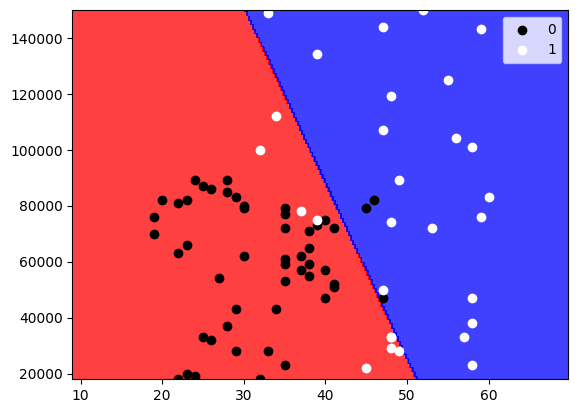

In [18]:
from matplotlib.colors import ListedColormap
X_set,y_set = sc.inverse_transform(X_test_sc),y_test
X1,X2 = np.meshgrid(np.arange(start=X_set[:,0].min()-10,stop=X_set[:,0].max()+10,step=0.25),
                    np.arange(start=X_set[:,1].min()-10,stop=X_set[:,1].max()+10,step=0.25))
plt.contourf(X1,X2,classifier.predict(sc.transform(np.array([X1.ravel(),X2.ravel()]).T)).reshape(X1.shape),
             alpha=0.75,cmap=ListedColormap(('red','blue')))
plt.xlim(X1.min(),X1.max())
plt.ylim(X2.min(),X2.max())
for i,j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set==j,0],X_set[y_set==j,1],c = ListedColormap(("black","white"))(i),label=j)
plt.legend()
